In [10]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn import cluster

(100, 2)


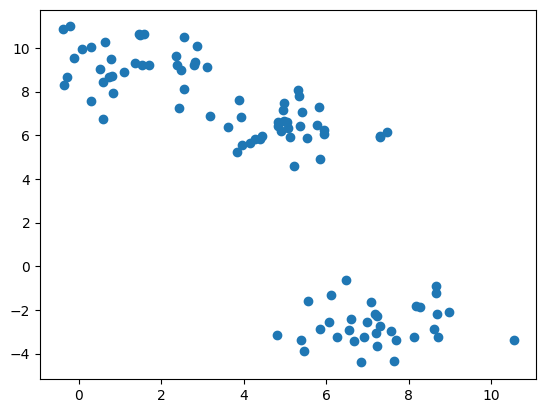

In [11]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples = 100, n_features = 2, random_state = 32)
print(X.shape)

plt.scatter(X[:,0],X[:,1])

In [62]:
def init_centr(k_clusters, X):
    i = 0
    j = 0
    centr_matrix = {}
    for j in range(X.shape[1]):
        centr_matrix = np.array(np.random.uniform(min(X[:,j]), max(X[:,j]), (k_clusters, X.shape[1])))
    return centr_matrix


    

In [63]:
init_centr(2, X)

array([[ 7.56899831,  3.06169249],
       [ 9.10619066, -1.78582884]])

In [64]:
def distancia(k_clusters, X, centroids):
    clusters = {}

    for k in range(k_clusters):
        clusters[k] = []

    for p in range(X.shape[0]):
        x = X[p, :]
        
        dist = {}
        for d in range(k_clusters):
            dist[d] = np.sum((x - centroids[d]) ** 2)
        
        dist_min = min(dist.values())
        
        for i, value in dist.items():
            if value == dist_min:
                clusters[i].append(x)
            break

    return clusters


In [66]:
distancia(2, X, init_centr(2, X))

{0: [array([2.36114351, 9.6422779 ]),
  array([ 2.56252317, 10.47970456]),
  array([0.74225629, 8.66043857]),
  array([0.79236328, 9.50023955]),
  array([-0.11488866,  9.51641908]),
  array([ 1.49172707, 10.57291124]),
  array([1.52721567, 9.2354772 ]),
  array([ 1.45967113, 10.62648704]),
  array([1.10653055, 8.87955857]),
  array([-0.20909572, 10.98135212]),
  array([-0.28507156,  8.64608988]),
  array([ 2.87577712, 10.10174026]),
  array([1.3562495 , 9.31687394]),
  array([-0.39187751, 10.86270639]),
  array([0.5187837 , 9.04947064]),
  array([-0.37051954,  8.30566305]),
  array([ 1.57061271, 10.6266794 ]),
  array([0.80158108, 8.72251995]),
  array([ 0.64264097, 10.27144269]),
  array([0.5762642 , 8.43360008]),
  array([0.06981958, 9.96597581]),
  array([1.69697842, 9.19990852]),
  array([2.37617219, 9.23485259]),
  array([ 0.30751637, 10.04529054]),
  array([2.81067691, 9.3521614 ])],
 1: []}

In [67]:
def recalculo_centroides(k_clusters, clusters):
    centr_matrix = {}
    for k in range(k_clusters):
        centr_matrix[k] = np.mean(clusters[k], axis=0)
    return centr_matrix

In [68]:
recalculo_centroides(2, X)

{0: np.float64(1.9853514366810956), 1: np.float64(6.00171070301366)}

In [72]:
def k_means(k_clusters, X, max_iter = 100):
    centroids = init_centr(k_clusters, X)
    print(type(centroids[0]))
    print(centroids[0]) 
    
    for _ in range(max_iter):
        clusters = distancia(k_clusters, X, centroids)
        new_centroids = recalculo_centroides(k_clusters, clusters)
        if all(len(clusters[k]) > 0 for k in range(k_clusters)):
            eta = 0
        else:
            centroids = init_centr(k_clusters, X)
            continue

        for k in range(k_clusters):
            eta += np.sum((centroids[k] - new_centroids[k]) ** 2)

        if eta < 1e-6:
            break
        centroids = new_centroids
    return clusters, centroids



In [73]:
k_means(2, X)

<class 'numpy.ndarray'>
[5.22059748 7.49529673]


/home/michele/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/michele/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


({0: [array([ 5.54948204, -1.57877916]),
   array([ 7.68343047, -3.36104801]),
   array([ 5.38987322, -3.39751713]),
   array([ 8.66214873, -1.23268862]),
   array([ 8.26541008, -1.87238464]),
   array([ 7.24022968, -3.64390563]),
   array([ 8.69929419, -3.22625104]),
   array([ 6.60297331, -2.4315964 ]),
   array([ 7.23090094, -2.25606397]),
   array([ 6.48286208, -0.60535344]),
   array([ 8.98320054, -2.08946305]),
   array([10.54149789, -3.3780303 ]),
   array([ 6.66748167, -3.43406205]),
   array([ 4.80928964, -3.13646081]),
   array([ 6.54562133, -2.9373502 ]),
   array([ 8.69136611, -2.19464506]),
   array([ 7.17860841, -2.19420242]),
   array([ 8.64957587, -0.88259589]),
   array([ 7.2174085 , -3.07374082]),
   array([ 7.5669363 , -2.97073937]),
   array([ 6.11046831, -1.32772692]),
   array([ 8.11584305, -3.22719161]),
   array([ 7.30831841, -2.73111396]),
   array([ 6.97668726, -2.56326554]),
   array([ 7.08885213, -1.62882267]),
   array([ 7.63156495, -4.32910219]),
   array(

In [74]:
from sklearn.cluster import KMeans

# Il tuo k-means
my_clusters, my_centroids = k_means(2, X)

# Sklearn k-means
sklearn_km = KMeans(n_clusters=2, random_state=42)
sklearn_km.fit(X)

# Confronto centroidi
print("Tuoi centroidi:")
for k in range(2):
    print(f"  Cluster {k}: {my_centroids[k]}")

print("\nCentroidi sklearn:")
print(sklearn_km.cluster_centers_)

# Confronto numero di punti per cluster
print("\nTuoi cluster - punti per cluster:")
for k in range(2):
    print(f"  Cluster {k}: {len(my_clusters[k])} punti")

print("\nSklearn - punti per cluster:")
unique, counts = np.unique(sklearn_km.labels_, return_counts=True)
for k, c in zip(unique, counts):
    print(f"  Cluster {k}: {c} punti")

<class 'numpy.ndarray'>
[9.46265113 7.77504129]
Tuoi centroidi:
  Cluster 0: [-1.74671624 -0.12694297]
  Cluster 1: [-3.49063072  6.39643294]

Centroidi sklearn:
[[ 7.23645533 -2.66300751]
 [ 3.17121069  7.80630512]]

Tuoi cluster - punti per cluster:
  Cluster 0: 39 punti
  Cluster 1: 0 punti

Sklearn - punti per cluster:
  Cluster 0: 34 punti
  Cluster 1: 66 punti
